# K-NN Classifier

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from time import time
from joblib import Parallel, delayed
import multiprocessing

In [ ]:
df = pd.read_csv("../datasets/airlines_delay.csv", sep=",")
AirlineUnique = df.Airline.unique()
AirportFromUnique = df.AirportFrom.unique()
AirportToUnique = df.AirportTo.unique()
Airlinelst = list(range(len(AirlineUnique)))
df['NumAirline'] = df['Airline']
df['NumAirline'].replace(AirlineUnique, Airlinelst, inplace=True)
AirportFromlst = list(range(len(AirportFromUnique)))
df['NumAirportFrom'] = df['AirportFrom']
df['NumAirportFrom'].replace(AirportFromUnique, AirportFromlst, inplace=True)
AirportTolst = list(range(len(AirportToUnique)))
df['NumAirportTo'] = df['AirportTo']
df['NumAirportTo'].replace(AirportToUnique, AirportTolst, inplace=True)

df = df.sample(n=10000)
X = df[["Length","NumAirline","NumAirportFrom","NumAirportTo","DayOfWeek"]]
y = df['Class']


/var/folders/61/4f_9vd3x7c9_5dsr15qd4fww0000gn/T/ipykernel_38834/3641257505.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['NumAirline'].replace(AirlineUnique, Airlinelst, inplace=True)
/var/folders/61/4f_9vd3x7c9_5dsr15qd4fww0000gn/T/ipykernel_38834/3641257505.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_d

In [9]:
X_simulated_small, y_simulated_small = make_classification(n_samples=300, n_features=6, n_classes=2, random_state=1)
X_simulated_large, y_simulated_large = make_classification(n_samples=15000, n_features=6, n_classes=2, random_state=1)

In [10]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
X_std = X_std
y = y.values


Minimum error:- 0.3975 at K = 11


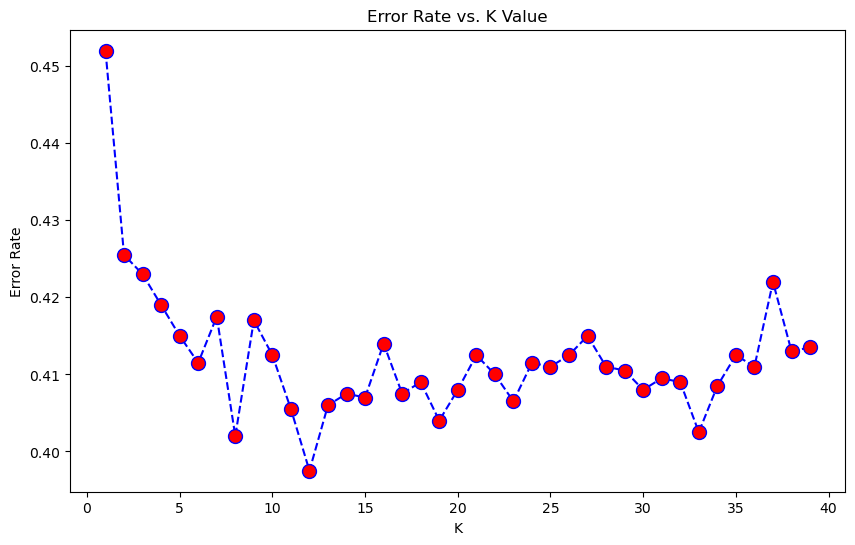

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.2, random_state=1, shuffle = True)
error_rate = []
for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='blue', linestyle='dashed', 
         marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
print("Minimum error:-",min(error_rate),"at K =",error_rate.index(min(error_rate)))

In [12]:
from math import sqrt

def euclidean(row1, row2):
    return sqrt(np.sum((row1 - row2)**2))

def test_accuracy(true, pred):
    return sum(a==b for a,b in zip(true,pred))/len(true)

# Example of calculating Euclidean distance :: from source no changes
# calculate the Euclidean distance between two vectors
from math import sqrt

def euclidean(row1, row2):
    '''This function returns the euclidean distance between two rows'''
    dist = 0.0
    for i in range(len(row1)-1):
        dist += (row1[i] - row2[i])**2
    return sqrt(dist)

def get_neighbors(train, test_row, num_neighbors): # get neighbors
    '''This function returns the rows frow the training data based on the smallest distances'''
    i = 0
    index_list = list()
    distances = list()
    for train_row in train:
        dist = euclidean(test_row, train_row)
        distances.append((train_row, dist, i))
        i += 1
        distances.sort(key=lambda tup: tup[1])
    neighbors = list()
    for i in range(num_neighbors):
        neighbors.append((distances[i][0],distances[i][2]))
    return neighbors

def predict_classification(x_train, y_train, test_row, num_neighbors):
    neighbors = get_neighbors(x_train, test_row, num_neighbors)
    index_list = list()
    for i in neighbors:
        index_list.append(i[1])
    output_values = y_train[index_list].tolist()
    prediction = max(set(output_values), key=output_values.count)
    return prediction


In [ ]:
# Simulated Study KNN (small data)
start=time()
acc=[]
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X_simulated_small,y_simulated_small,test_size=0.2,random_state=i)
    num_cores = multiprocessing.cpu_count()
    inputs = range(len(X_test))
    def multi_run(t):
        return predict_classification(X_train,y_train,X_test[t],25)
    results = Parallel(n_jobs=num_cores)(delayed(multi_run)(i) for i in inputs)
    acc.append(test_accuracy(y_test, results))
print('Prediction accuracy of model:', sum(acc)/len(acc))
print('Training time for KNN:', time()-start)


Prediction accuracy of model: 0.9133333333333334
Training time for KNN: 1.7317631244659424


In [14]:
# Simulated Study KNN (large data)
start=time()
acc=[]
for i in range(1):
    X_train, X_test, y_train, y_test = train_test_split(X_simulated_large,y_simulated_large,test_size=0.2,random_state=i)
    num_cores = multiprocessing.cpu_count()
    inputs = range(len(X_test))
    def multi_run(t):
        return predict_classification(X_train,y_train,X_test[t],25)
    results = Parallel(n_jobs=num_cores)(delayed(multi_run)(i) for i in inputs)
    acc.append(test_accuracy(y_test, results))
print('Prediction accuracy of model:', sum(acc)/len(acc))
print('Training time for KNN:', time()-start)


KeyboardInterrupt: 

In [ ]:
# Real data study for KNN
start=time()
acc=[]
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X_std,y,test_size=0.2,random_state=i)
    num_cores = multiprocessing.cpu_count()
    inputs = range(len(X_test))
    def predict_classification(train_X, train_y, test_row, k):
        distances=[(euclidean(test_row, row), train_y[idx]) for idx,row in enumerate(train_X)]
        distances.sort(key=lambda tup:tup[0])
        neighbors=[label for _,label in distances[:k]]
        return max(set(neighbors), key=neighbors.count)
    def multi_run(t):
        return predict_classification(X_train,y_train,X_test[t],25)
    results = Parallel(n_jobs=num_cores)(delayed(multi_run)(i) for i in inputs)
    acc.append(test_accuracy(y_test, results))
print('Prediction accuracy of model:', sum(acc)/len(acc))
print('Training time for KNN:', time()-start)
